# 04 — Naive baselines

ADR-0008: the mechanism must beat two naive baselines on the tracking-error/cost
frontier — *"periodic manual rebalance, threshold rebalance via a generic aggregator."*
Both baselines here trade the LP's own held balances (the LP is the *taker*, unlike the
mechanism itself) against a deep external constant-product pool (`aqua_sim.baselines`,
reusing `curve.py`'s own equal-weight math so fee and slippage come from one real
formula, not a hand-fit approximation).

Both baselines also pay a flat, explicitly-labeled **placeholder** gas cost per
transaction — real gas numbers don't exist yet for the full on-chain implementation
(`BLEUDEV-265` is still open). This is flagged here and in `baselines.py`'s own docstring,
not silently assumed to be accurate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.baselines import GenericDexConfig, rebalance_to_target
from aqua_sim.market import simulate_price_path
from aqua_sim.metrics import cost_of_rebalancing, frictionless_reference_path, portfolio_value, tracking_error, weight_a

## 1. A single rebalance trade lands close to target

Checked at a realistic portfolio scale ($20,000) — at toy scale a flat gas cost would
dominate the result by itself, which would be an artifact of the test's own scale, not a
property of the rebalance logic.

In [2]:
dex_config = GenericDexConfig(fee=0.003, depth_b=10_000_000.0, gas_cost_b=5.0)

balance_a, balance_b = 8_000.0, 12_000.0  # weight_a = 0.4, target 0.5
new_a, new_b = rebalance_to_target(balance_a, balance_b, price_a_in_b=1.0, target_weight_a=0.5, config=dex_config)
new_weight = weight_a(new_a, new_b, 1.0)

assert abs(new_weight - 0.5) < 0.001, f"should land close to target, got {new_weight}"
print(f"rebalanced from weight_a=0.400 to weight_a={new_weight:.5f} (target 0.5) -- fee + tiny slippage + gas account for the residual")

# Already-at-target: only gas is deducted, no trade needed.
at_target_a, at_target_b = rebalance_to_target(10_000.0, 10_000.0, price_a_in_b=1.0, target_weight_a=0.5, config=dex_config)
assert at_target_a == 10_000.0
assert abs(at_target_b - (10_000.0 - dex_config.gas_cost_b)) < 1e-9
print(f"already at target: only gas ({dex_config.gas_cost_b}) deducted, no trade needed")

rebalanced from weight_a=0.400 to weight_a=0.49997 (target 0.5) -- fee + tiny slippage + gas account for the residual
already at target: only gas (5.0) deducted, no trade needed


## 2. Periodic rebalance, run against a full year of synthetic market moves

Same GBM price path style as `03_endogenous_flow.ipynb` — rebalance to exact target on a
fixed schedule (weekly here), regardless of how far drifted, paying fee + slippage + gas
each time.

In [3]:
N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)
price_path = simulate_price_path(N_STEPS, DT, sigma_annual=0.8, seed=42)  # same seed as notebook 03, for comparability

period_steps = 12 * 24 * 7  # weekly

bal_a, bal_b = 10_000.0, 10_000.0
bal_a_path = np.empty(N_STEPS + 1)
bal_b_path = np.empty(N_STEPS + 1)
bal_a_path[0], bal_b_path[0] = bal_a, bal_b
n_rebalances = 0

for t in range(1, N_STEPS + 1):
    if t % period_steps == 0:
        bal_a, bal_b = rebalance_to_target(bal_a, bal_b, price_path[t], 0.5, dex_config)
        n_rebalances += 1
    bal_a_path[t] = bal_a
    bal_b_path[t] = bal_b

assert np.all(bal_a_path > 0) and np.all(bal_b_path > 0), "balances must stay positive throughout"

periodic_value_path = np.array([portfolio_value(a, b, p) for a, b, p in zip(bal_a_path, bal_b_path, price_path)])
periodic_reference = frictionless_reference_path(price_path, periodic_value_path[0], 0.5)
periodic_cost = cost_of_rebalancing(periodic_value_path, periodic_reference)
periodic_te = np.array([tracking_error(a, b, p, 0.5) for a, b, p in zip(bal_a_path, bal_b_path, price_path)])

print(f"periodic (weekly): {n_rebalances} rebalances, final cost={periodic_cost[-1]:.2f} ({periodic_cost[-1]/periodic_value_path[0]:.2%} of initial value), p95 tracking error={np.percentile(periodic_te, 95):.4%}")

periodic (weekly): 52 rebalances, final cost=4465.15 (22.33% of initial value), p95 tracking error=4.8540%


## 3. Threshold rebalance, same price path

Rebalances the moment drift exceeds a threshold, otherwise does nothing — checked here at
each step against the *current* weight (no schedule).

In [4]:
threshold = 0.05  # 5% drift triggers a rebalance

bal_a2, bal_b2 = 10_000.0, 10_000.0
bal_a2_path = np.empty(N_STEPS + 1)
bal_b2_path = np.empty(N_STEPS + 1)
bal_a2_path[0], bal_b2_path[0] = bal_a2, bal_b2
n_rebalances2 = 0

for t in range(1, N_STEPS + 1):
    price = price_path[t]
    if tracking_error(bal_a2, bal_b2, price, 0.5) > threshold:
        bal_a2, bal_b2 = rebalance_to_target(bal_a2, bal_b2, price, 0.5, dex_config)
        n_rebalances2 += 1
    bal_a2_path[t] = bal_a2
    bal_b2_path[t] = bal_b2

assert np.all(bal_a2_path > 0) and np.all(bal_b2_path > 0)

threshold_value_path = np.array([portfolio_value(a, b, p) for a, b, p in zip(bal_a2_path, bal_b2_path, price_path)])
threshold_reference = frictionless_reference_path(price_path, threshold_value_path[0], 0.5)
threshold_cost = cost_of_rebalancing(threshold_value_path, threshold_reference)
threshold_te = np.array([tracking_error(a, b, p, 0.5) for a, b, p in zip(bal_a2_path, bal_b2_path, price_path)])

assert np.percentile(threshold_te, 99) < threshold * 1.5, "threshold rebalance should keep drift roughly bounded near its own threshold"
print(f"threshold (5%): {n_rebalances2} rebalances, final cost={threshold_cost[-1]:.2f} ({threshold_cost[-1]/threshold_value_path[0]:.2%} of initial value), p95 tracking error={np.percentile(threshold_te, 95):.4%}")

threshold (5%): 28 rebalances, final cost=4468.76 (22.34% of initial value), p95 tracking error=4.0854%


## Visualization

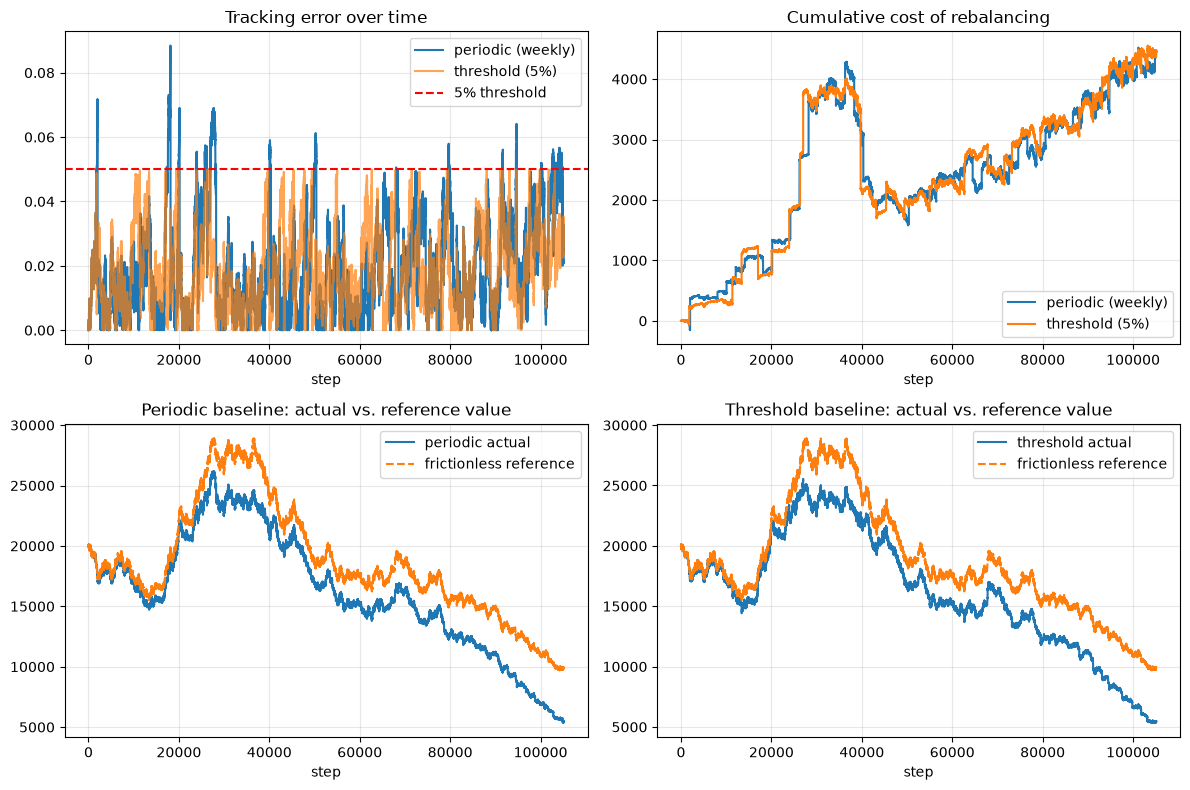

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(periodic_te, label="periodic (weekly)")
axes[0, 0].plot(threshold_te, label="threshold (5%)", alpha=0.7)
axes[0, 0].axhline(threshold, color="red", linestyle="--", label="5% threshold")
axes[0, 0].set_title("Tracking error over time")
axes[0, 0].set_xlabel("step")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(periodic_cost, label="periodic (weekly)")
axes[0, 1].plot(threshold_cost, label="threshold (5%)")
axes[0, 1].set_title("Cumulative cost of rebalancing")
axes[0, 1].set_xlabel("step")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(periodic_value_path, label="periodic actual")
axes[1, 0].plot(periodic_reference, label="frictionless reference", linestyle="--")
axes[1, 0].set_title("Periodic baseline: actual vs. reference value")
axes[1, 0].set_xlabel("step")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(threshold_value_path, label="threshold actual")
axes[1, 1].plot(threshold_reference, label="frictionless reference", linestyle="--")
axes[1, 1].set_title("Threshold baseline: actual vs. reference value")
axes[1, 1].set_xlabel("step")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Both baselines run correctly end to end on the same price path used in
`03_endogenous_flow.ipynb`, on the same cost/tracking-error metrics — so the numbers are
directly comparable:

| Approach | Final cost | % of initial value | p95 tracking error |
|---|---|---|---|
| Mechanism (notebook 03) | 725.57 | 3.63% | 0.48% |
| Periodic (weekly) | 4465.15 | 22.33% | 4.85% |
| Threshold (5%) | 4468.76 | 22.34% | 4.09% |

In this one arbitrary seed/config, the mechanism beats both baselines by a wide margin on
both KPIs at once — but this single path isn't the frontier result itself (a single path
can be lucky or unlucky, and "beats baselines" needs to hold across many realizations and
parameter choices, not one). `05_frontier_sweep.ipynb` runs many Monte Carlo repetitions
across a parameter grid for all three approaches and checks whether the mechanism's
frontier dominates, which is the actual ADR-0008 KPI.